In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

In [ ]:
datos = np.loadtxt("tov.dat", skiprows=1)
r = datos[:,0]
m = datos[:,1]
alpha = datos[:,2]
P = datos[:,3]
a_geo = datos[:,4]
rho = datos[:,5]
cs2 = datos[:,6]

if r.all() <= 14.154649425897176 :
    alpha = alpha * 0.66985726408768598

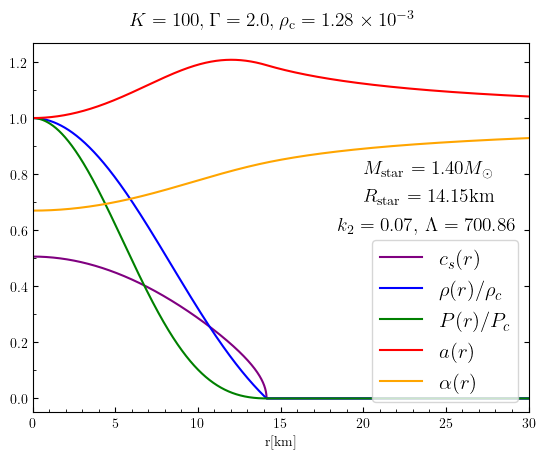

In [3]:
fig, ax = plt.subplots()
fig.suptitle(r'$K=100, \Gamma=2.0,\rho_{\rm c}=%1.2f \times 10^{-3}$' %1.28, fontsize=14, y = 0.95)
ax.plot(r,np.sqrt(cs2), color='purple', label='$c_s(r)$')
ax.plot(r,rho/rho[0], color='b', label=r'$\rho(r)/\rho_c$ ')
ax.plot(r,P/P[0], color='g',label=r'$P(r)/P_c$')
ax.plot(r,a_geo, color='r',label=r'$a(r)$')
ax.plot(r,alpha, color='orange',label=r'$\alpha(r)$')
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.tick_params(axis="both",which='both',direction="in")
ax.legend(loc=4,fontsize="15")
ax.set_xlabel(r"$\rm r [km]$")
ax.set_xlim(0,30)
ax.set_ylim(-0.05,)
ax.tick_params(bottom=True, top=False, left=True, right=True)
plt.text(20, 0.8, r'$M_{\rm star}= %1.2f M_\odot$' %1.40 , dict(size=14))
plt.text(20, 0.7, r'$R_{\rm star}= %1.2f \rm{km}$' %14.15 , dict(size=14))
plt.text(18.5, 0.6, r'$k_2 = 0.07,\,\Lambda=700.86$',dict(size=14))
plt.savefig("tovRK4_OMAR.pdf",dpi=300)
plt.show()

In [ ]:
H = datos[:,7]
beta = datos[:,8]

In [ ]:
plt.title(r"$a_0=0.5,\,\Delta r=0.003,\,k_2 = 0.07,\,\Lambda=700.86$", fontsize=13)
plt.plot(r,H,label=r"$H(r)$")
plt.plot(r,beta,label=r"$\beta(r)$")
#plt.yscale('log')
plt.xlim(0,14.15)
plt.xlabel(r"$\rm r\,[km]$")
plt.legend(loc="best",fontsize=15)
plt.savefig("TidalDef_reg_OMAR.pdf",dpi=300)

In [ ]:
dr = r[1] - r[0]

def cumulative_l2_norm_spherical(param, r, dx):
    weights = 4.0 * np.pi * r**2
    return np.sqrt(np.cumsum(param**2 * weights) * dx)

L2r_P = cumulative_l2_norm_spherical(P, r, dr)
L2r_a = cumulative_l2_norm_spherical(a_geo, r,dr)
L2r_H = cumulative_l2_norm_spherical(H, r,dr)

fig, axes = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=(6, 10))

axes[0].plot(r, L2r_P, color='blue')
axes[0].set_ylabel(r'$||P||_2(r)$')

axes[1].plot(r, L2r_a, color='blue')
axes[1].set_ylabel(r'$||a||_2(r)$')

axes[2].plot(r, L2r_H, color='blue')
axes[2].set_ylabel(r'$||H||_2(r)$')

axes[2].set_xlabel('r')
plt.suptitle(r'Cumulative $L_2$ norm')
plt.tight_layout()
plt.show()

In [ ]:
L2_global = np.sqrt(np.sum(a_geo**2*4*np.pi*r**2) *  dr)
print(L2_global, L2r_a[-1])

In [4]:
print(a_geo)

[1.         1.         1.         ... 1.05021724 1.05021718 1.05021713]


In [ ]:
from scipy.interpolate import interp1d

# Load data
datos_300 = np.loadtxt("/home/omar/Desktop/tov_300kpts.dat", skiprows=1)
datos_600 = np.loadtxt("/home/omar/Desktop/tov_600kpts.dat", skiprows=1)
datos_1200 = np.loadtxt("/home/omar/Desktop/tov_1200kpts.dat", skiprows=1)

# Extract r and H
r_300, H_300 = 1.47651*datos_300[:,0], datos_300[:,8]
r_600, H_600 = 1.47651*datos_600[:,0], datos_600[:,8]
r_1200, H_1200 = 1.47651*datos_1200[:,0], datos_1200[:,8]

# Common domain
rmin = max(r_300.min(), r_600.min(), r_1200.min())
rmax = min(r_300.max(), r_600.max(), r_1200.max())
mask = (r_1200 >= rmin) & (r_1200 <= rmax)
r_1200_common = r_1200[mask]
H_1200_common = H_1200[mask]

# Interpolate coarser data onto fine grid
H_300_interp = interp1d(r_300, H_300, kind='cubic', fill_value="extrapolate")(r_1200_common)
H_600_interp = interp1d(r_600, H_600, kind='cubic', fill_value="extrapolate")(r_1200_common)

# Compute differences
diff1 = H_300_interp - H_600_interp
diff2 = H_600_interp - H_1200_common

print(np.shape(H_300))
print(np.shape(H_600))
print(np.shape(H_1200))

In [ ]:
H_600_on_300 = H_600[::2]
H_1200_on_600 = H_1200[::2]
H_1200_on_300 = H_1200[::4]
print(np.shape(H_600_on_300))
print(np.shape(H_1200_on_600))
print(np.shape(H_1200_on_300))

In [ ]:
dr_common = r_1200_common[1] - r_1200_common[0]
L2r_num = cumulative_l2_norm_spherical(diff1, r_1200_common,dr_common)
L2r_den = cumulative_l2_norm_spherical(diff2, r_1200_common,dr_common)
convergence_factor = L2r_num / L2r_den 

# Compute norms and convergence order
#norm_diff1 = np.linalg.norm(diff1)
#norm_diff2 = np.linalg.norm(diff2)
#p = np.log(norm_diff1 / norm_diff2) / np.log(2)
#print(f"Estimated convergence order p = {p:.3f}")

# Plot ratio
#ratio = np.abs(diff1 / diff2)
plt.plot(r_1200_common, convergence_factor, label=f'Local ratio (expected ~16 for 4th order)')
plt.axhline(16, color='k', linestyle='--', label='Expected (4th order)')
#plt.yscale('log')
plt.xlabel(r"r [km]")
plt.xlim(-0.1,)
#plt.ylabel("|Δ_coarse / Δ_medium|")
plt.legend()
plt.show()

In [ ]:
# Compute differences
diff1 = H_300 - H_600_on_300
diff2 = H_600_on_300 - H_1200_on_300

dr_300 = r_300[1] - r_300[0]
L2r_num = cumulative_l2_norm_spherical(diff1, r_300,dr_300)
L2r_den = cumulative_l2_norm_spherical(diff2, r_300,dr_300)
convergence_factor = L2r_num / L2r_den 

plt.plot(r_300, convergence_factor, label=f'Local ratio (expected ~16 for 4th order)')
plt.axhline(16, color='k', linestyle='--', label='Expected (4th order)')
plt.xlabel(r"r [km]")
plt.xlim(-0.1,)
plt.legend()
plt.show()

In [ ]:
norm_diff1 = np.linalg.norm(H_300_interp - H_600_interp)
norm_diff2 = np.linalg.norm(H_600_interp - H_1200_common)
p = np.log(norm_diff1 / norm_diff2) / np.log(2)
print(f"Estimated convergence order p = {p:.3f}")

In [ ]:
# assume same domain and uniform grids
H1200_on_600 = H_1200[::2]
H1200_on_300 = H_1200[::4]

diff1 = H_300 - H_600[::2]
diff2 = H_600 - H1200_on_600[1:]

def l2_spherical_global(f, r):
    dr = r[1] - r[0]
    return np.sqrt(np.sum(f**2 * 4*np.pi*r**2) * dr)

L2_num = l2_spherical_global(diff1, r_300)
L2_den = l2_spherical_global(diff2, r_600)

Q = L2_num / L2_den
p_obs = np.log2(Q)

print("Q =", Q, " observed order p =", p_obs)


In [ ]:
i = 50  # well inside star

e1 = abs(H_300[i] - H_600[2*i+2])
e2 = abs(H_600[i] - H1200_on_600[i+1])

Qp = e1 / e2
pp = np.log2(Qp)
print(Qp, pp)

In [ ]:
# Extract P
P_300 = datos_300[:,3]
P_600 = datos_600[:,3]
P_1200 = datos_1200[:,3]

P_600_on_300 = P_600[::2]
P_1200_on_600 = P_1200[::2]
P_1200_on_300 = P_1200[::4]

# Compute differences
diff1 = P_300 - P_600_on_300
diff2 = P_600_on_300 - P_1200_on_300

dr_300 = r_300[1] - r_300[0]
L2r_num = cumulative_l2_norm_spherical(diff1, r_300,dr_300)
L2r_den = cumulative_l2_norm_spherical(diff2, r_300,dr_300)
Q_P = L2r_num / L2r_den 

plt.plot(r_300, Q_P, color='green',label=f'Local ratio (expected ~16 for 4th order)')
plt.axhline(16, color='k', linestyle='--', label='Expected (4th order)')
plt.xlabel(r"r [km]")
plt.xlim(-0.1,)
plt.axhline(2)
plt.legend()
plt.show()